In [28]:
import torch
import numpy as np
import matplotlib . pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [29]:
def l_System_generator(axiom, rules, iterations):
    current = axiom
    for _ in range(iterations):
        current = ''.join(rules.get(ch, ch) for ch in current)
    return current

axiom = "A"
rules = {'A': 'B-A-B', 'B': 'A+B+A'}

iterations = 10
l_system_string = l_System_generator(axiom, rules, iterations)


In [30]:
Golden_Ratio = (1 + np.sqrt(5)) / 2
angle_a = 180/ Golden_Ratio**2
angle_b = 180/Golden_Ratio

deltas = torch.tensor(
    [
    angle_a if ch == '+' else (-angle_b if ch == '-' else 0.0)
    for ch in l_system_string
    ])

headings = torch.cumsum(deltas, dim=0) * np.pi/180
is_forward = torch.tensor([1.0 if ch == 'A' else 0.0 for ch in l_system_string])

dx = torch.cos(headings) * is_forward
dy = torch.sin(headings) * is_forward

x = torch.cumsum(dx, dim=0)
y = torch.cumsum(dy, dim=0)

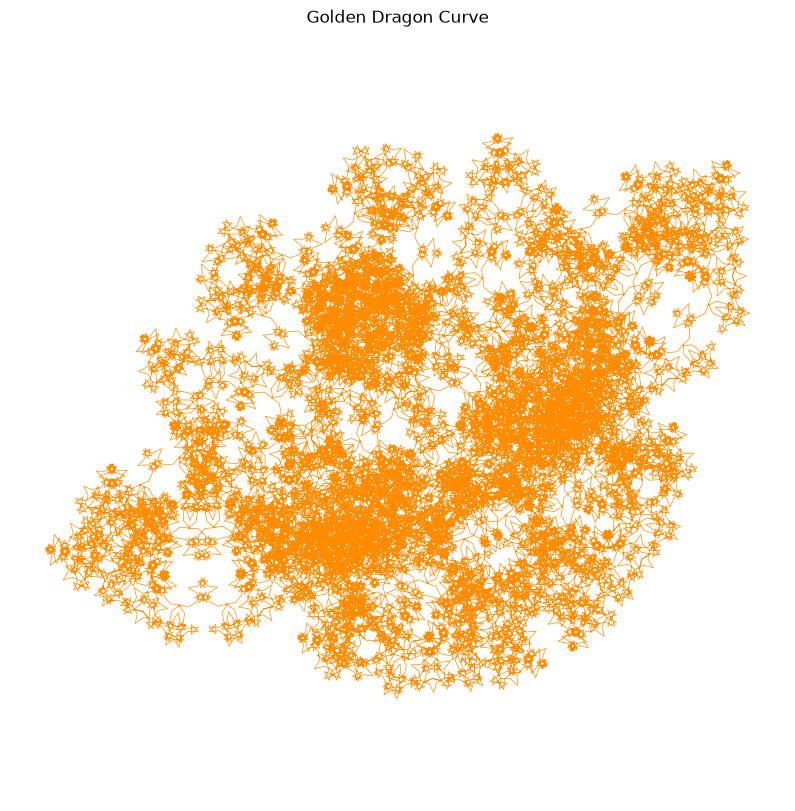

In [31]:
plt.figure(figsize=(10, 10))
plt.plot(x.numpy(), y.numpy(), linewidth=0.5, color='darkorange')
plt.axis('equal')
plt.axis('off')
plt.title('Golden Dragon Curve')
plt.show()